# Midterm Project
### William Miller
### ECGR 4116
### DUE: April 17, 2026

## Data Loading and Preprocessing

In [1]:
# Directory paths used in this project
# Replace with the directory path you will be using when recreating
TRAIN_A_PATH = "/home/wbfm/Documents/School/AI-biomed/SRGAN/Dataset/train"    # The path for accessing the train dataset for training model A
TEST_A_PATH = "/home/wbfm/Documents/School/AI-biomed/SRGAN/Dataset/test"    # The path to access the test dataset for verifying model A accuracy
GEN_PATH = "/home/wbfm/Documents/School/AI-biomed/SRGAN/gen-dataset"   # The path for where you save generated images for training model B

BATCH_SIZE = 32

In [2]:
# Load libraries
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as op
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import random_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Set up GPU training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # verify it says 'cuda'

cuda


In [3]:
# Select transformations
transform_selection = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create tensor dataset
dataset = datasets.ImageFolder(root= TRAIN_A_PATH, transform= transform_selection)

# Convert and Drusen and DME to same label for binary classification: Diseased (1) vs Healthy (0)
print(dataset.classes)
print(dataset.class_to_idx)
print(set(dataset.targets))

dataset.targets = [0 if label == 2 else 1 for label in dataset.targets]
dataset.imgs = [(path, 0 if label == 2 else 1) for path, label in dataset.imgs]
dataset.samples = [(path, 0 if label == 2 else 1) for path, label in dataset.samples]

# Verify
print("\nNew labels")
print(set(dataset.targets))

# Update metadata
dataset.classes = ['NORMAL', 'DISEASED']
dataset.class_to_idx = {'NORMAL': 0, 'DISEASED': 1}
print(dataset.classes)
print(dataset.class_to_idx)

# Create data loader and set batch size

dataloader = DataLoader(dataset, batch_size= BATCH_SIZE, shuffle= True, num_workers= 0)

['DME', 'DRUSEN', 'NORMAL']
{'DME': 0, 'DRUSEN': 1, 'NORMAL': 2}
{0, 1, 2}

New labels
{0, 1}
['NORMAL', 'DISEASED']
{'NORMAL': 0, 'DISEASED': 1}


## Train binary classifier A

In [4]:
# Set up model
model = resnet18(weights= ResNet18_Weights.DEFAULT)

# Freeze weights of layers for fine-tuning
for parameter in model.parameters():
    parameter.requires_grad = False

# Check input/output features of final layer
print(model.fc)

model.fc = nn.Linear(in_features= 512, out_features= 2)

# Verify
print(model.fc)

# Move to GPU training
model = model.to(device)

# Create
criterion = nn.CrossEntropyLoss()
optimizer = op.Adam(model.fc.parameters(), lr=0.001)

# Training loop
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    for images, labels in dataloader:
        #print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {loss.item():.4f}")
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Save model
torch.save(model.state_dict(), 'modelA.pth')

Linear(in_features=512, out_features=1000, bias=True)
Linear(in_features=512, out_features=2, bias=True)


## Test model performance to ensure it is suitable for remainder of assignment

In [5]:
# Prepare model from saved file (In case Kernel reset)
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(in_features=512, out_features=2)
model.load_state_dict(torch.load('modelA.pth'))
model = model.to(device)

# Prepare test data set
test_trans = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root= TEST_A_PATH, transform= test_trans)

test_dataset.targets = [0 if label == 2 else 1 for label in test_dataset.targets]
test_dataset.imgs = [(path, 0 if label == 2 else 1) for path, label in test_dataset.imgs]
test_dataset.samples = [(path, 0 if label == 2 else 1) for path, label in test_dataset.samples]

# Create test dataloader
test_dataloader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle= True)

# Evaluate model A: Binary classifier
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 86.19%


## Train SRGAN to generate 128x128 images

In [6]:
# Generator
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        # Two conv layers with batch norm — learns features at same resolution
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),  # stabilizes training
            nn.PReLU(),                # learnable activation function
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
    
    def forward(self, x):
        # Skip connection: add input to output so gradients flow easily
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, num_residual_blocks=8):
        super(Generator, self).__init__()
        
        # First conv layer: converts 3-channel image to 64 feature maps
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.PReLU()
        )
        
        # Stack of residual blocks: deep feature extraction without losing info
        self.residuals = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_residual_blocks)]
        )
        
        # Conv after residuals before upsampling
        self.post_residual = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64)
        )
        
        # Upsampling: PixelShuffle rearranges pixels to increase resolution
        # 32x32 -> 64x64 -> 128x128 (two 2x upscales)
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),  # 256 channels -> 64 channels, doubles spatial size
            nn.PReLU(),
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )
        
        # Final conv: maps 64 feature maps back to 3-channel RGB image
        self.output = nn.Conv2d(64, 3, kernel_size=9, padding=4)
        # Tanh squishes output to [-1, 1] to match normalized input range
        self.tanh = nn.Tanh()
    
    def forward(self, x):
        initial = self.initial(x)
        residual = self.residuals(initial)
        post = self.post_residual(residual) + initial  # skip connection
        upsampled = self.upsample(post)
        return self.tanh(self.output(upsampled))

In [7]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Helper function to build conv blocks
        # stride=2 halves the spatial dimensions (downsampling)
        # stride=1 keeps dimensions the same but increases channels
        def block(in_channels, out_channels, stride):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2)  # LeakyReLU is standard for discriminators
            )
        
        self.model = nn.Sequential(
            # Initial conv: no batch norm on first layer (common practice)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            # Progressively increase channels while decreasing spatial size
            block(64, 64, 2),    # 128x128 -> 64x64
            block(64, 128, 1),
            block(128, 128, 2),  # 64x64 -> 32x32
            block(128, 256, 1),
            block(256, 256, 2),  # 32x32 -> 16x16
            block(256, 512, 1),
            block(512, 512, 2),  # 16x16 -> 8x8
            # Collapse spatial dimensions to single value per channel
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            # Fully connected classifier
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1),
            nn.Sigmoid()  # output between 0 and 1 (fake vs real probability)
        )
    
    def forward(self, x):
        return self.model(x)

In [8]:
# Initialize
generator = Generator().to(device)
discriminator = Discriminator().to(device)

g_optimizer = op.Adam(generator.parameters(), lr=0.0001)
d_optimizer = op.Adam(discriminator.parameters(), lr=0.0001)

criterion_adv = nn.BCELoss()
criterion_content = nn.MSELoss()

downscale = transforms.Resize((32, 32))

NUM_EPOCHS_SRGAN = 50
CHECKPOINT_INTERVAL = 10
os.makedirs("checkpoints/SRGAN-checkpoints/discriminator", exist_ok= True)
os.makedirs("checkpoints/SRGAN-checkpoints/generator", exist_ok= True)

for epoch in range(NUM_EPOCHS_SRGAN):
    g_loss_total = 0
    d_loss_total = 0
    
    for real_hr, _ in dataloader:
        real_hr = real_hr.to(device)
        batch_size = real_hr.size(0)
        
        # Downscale to get low-res input
        low_res = F.interpolate(real_hr, size=(32, 32), mode='bicubic', align_corners=False)
        
        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # Train Discriminator
        d_optimizer.zero_grad()
        
        real_pred = discriminator(real_hr)
        d_real_loss = criterion_adv(real_pred, real_labels)
        
        fake_hr = generator(low_res).detach()  # detach so we don't backprop into generator
        fake_pred = discriminator(fake_hr)
        d_fake_loss = criterion_adv(fake_pred, fake_labels)
        
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()
        
        # Train Generator
        g_optimizer.zero_grad()
        
        fake_hr = generator(low_res)
        fake_pred = discriminator(fake_hr)
        
        adv_loss = criterion_adv(fake_pred, real_labels)
        content_loss = criterion_content(fake_hr, real_hr)
        g_loss = content_loss + 0.001 * adv_loss
        
        g_loss.backward()
        g_optimizer.step()
        
        g_loss_total += g_loss.item()
        d_loss_total += d_loss.item()
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_SRGAN} | G Loss: {g_loss_total/len(dataloader):.4f} | D Loss: {d_loss_total/len(dataloader):.4f}")
    
    # Checkpoint
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        torch.save(generator.state_dict(), f'checkpoints/SRGAN-checkpoints/generator/generator_epoch{epoch+1}.pth')
        torch.save(discriminator.state_dict(), f'checkpoints/SRGAN-checkpoints/discriminator/discriminator_epoch{epoch+1}.pth')

    # Save final copy of generator in main directory
    if epoch == 49:
        torch.save(generator.state_dict(), f'generator_epoch{epoch+1}.pth')

Epoch 1/50 | G Loss: 0.7692 | D Loss: 0.4516
Epoch 2/50 | G Loss: 0.5312 | D Loss: 0.0125
Epoch 3/50 | G Loss: 0.5170 | D Loss: 0.0041
Epoch 4/50 | G Loss: 0.5081 | D Loss: 0.0019
Epoch 5/50 | G Loss: 0.5047 | D Loss: 0.0011
Epoch 6/50 | G Loss: 0.4991 | D Loss: 0.3460
Epoch 7/50 | G Loss: 0.4939 | D Loss: 0.0905
Epoch 8/50 | G Loss: 0.4937 | D Loss: 0.0098
Epoch 9/50 | G Loss: 0.4920 | D Loss: 0.0045
Epoch 10/50 | G Loss: 0.4902 | D Loss: 0.0032
Epoch 11/50 | G Loss: 0.4893 | D Loss: 0.0020
Epoch 12/50 | G Loss: 0.4889 | D Loss: 0.0017
Epoch 13/50 | G Loss: 0.4874 | D Loss: 0.0013
Epoch 14/50 | G Loss: 0.4862 | D Loss: 0.0011
Epoch 15/50 | G Loss: 0.4859 | D Loss: 0.0009
Epoch 16/50 | G Loss: 0.4843 | D Loss: 0.0008
Epoch 17/50 | G Loss: 0.4837 | D Loss: 0.0007
Epoch 18/50 | G Loss: 0.4844 | D Loss: 0.0007
Epoch 19/50 | G Loss: 0.4836 | D Loss: 0.0005
Epoch 20/50 | G Loss: 0.4829 | D Loss: 0.0005
Epoch 21/50 | G Loss: 0.4828 | D Loss: 0.0004
Epoch 22/50 | G Loss: 0.4825 | D Loss: 0.00

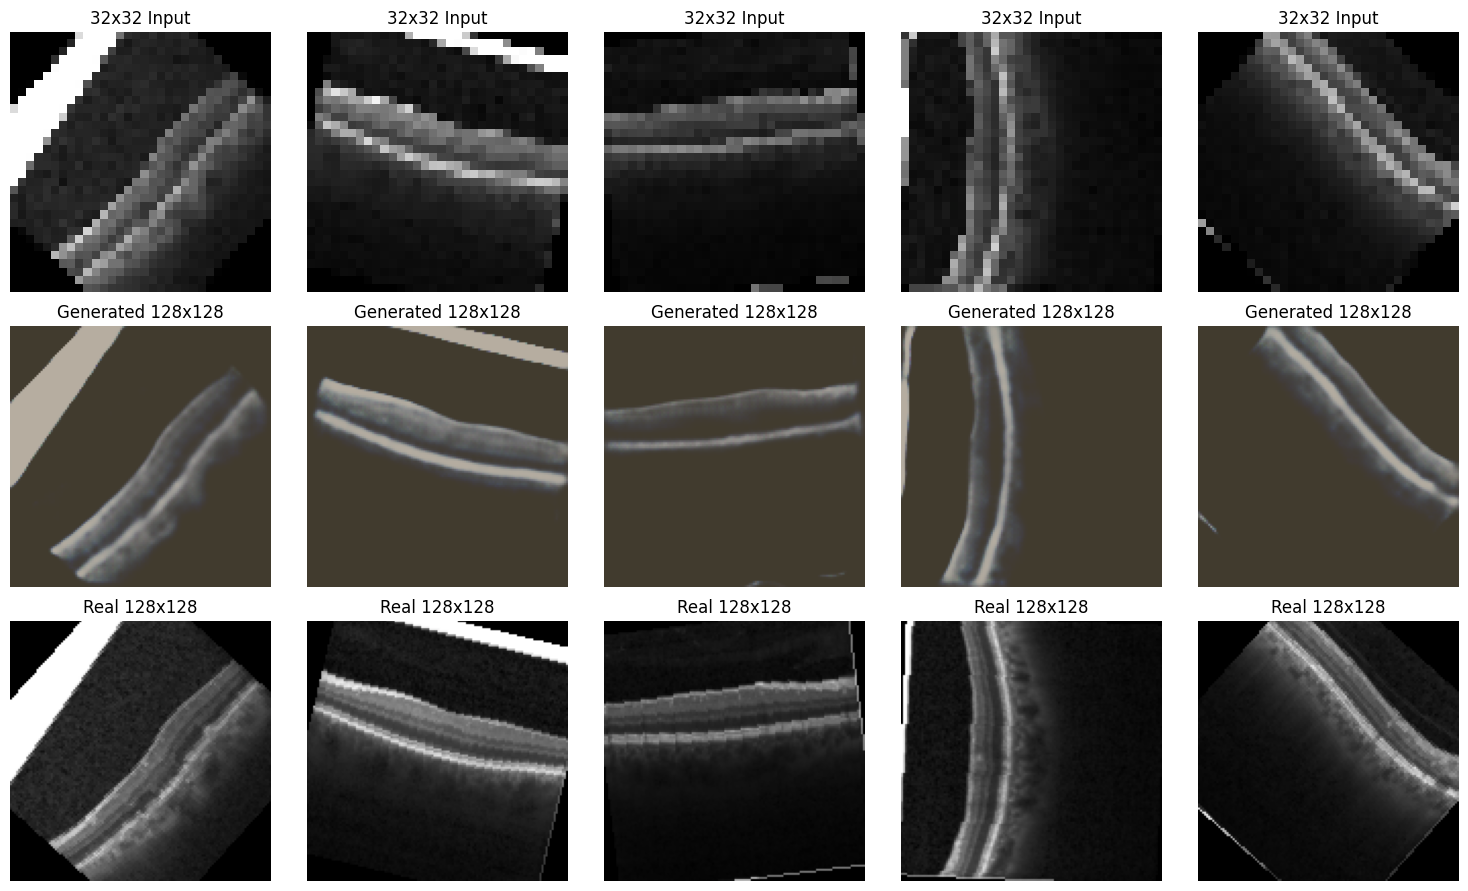

In [9]:
# Prepare model from saved file (In case Kernel reset)
generator = Generator().to(device)
generator.load_state_dict(torch.load('generator_epoch50.pth'))

# Print some of the images from the generator
def denormalize(tensor):
    # Reverse the ImageNet normalization so images display correctly
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

generator.eval()
with torch.no_grad():
    real_hr, _ = next(iter(dataloader))
    real_hr = real_hr.to(device)
    low_res = F.interpolate(real_hr, size=(32, 32), mode='bicubic', align_corners=False)
    fake_hr = generator(low_res)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Low res
    axes[0, i].imshow(denormalize(low_res[i]).permute(1, 2, 0))
    axes[0, i].set_title("32x32 Input")
    axes[0, i].axis('off')
    # Generated
    axes[1, i].imshow(denormalize(fake_hr[i]).permute(1, 2, 0))
    axes[1, i].set_title("Generated 128x128")
    axes[1, i].axis('off')
    # Real
    axes[2, i].imshow(denormalize(real_hr[i]).permute(1, 2, 0))
    axes[2, i].set_title("Real 128x128")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

# Train binary classifier model B on generated dataset

In [10]:
# Create directory for saving generated images
os.makedirs('gen-dataset/DME', exist_ok= True)
os.makedirs('gen-dataset/DRUSEN', exist_ok= True)
os.makedirs('gen-dataset/NORMAL', exist_ok= True)

# Run all images through generator after downscaling and save to new gen-dataset directory
from torchvision.utils import save_image

with torch.no_grad():
    for i, (real_hr, label) in enumerate(dataloader):
        # Produce generated images
        real_hr = real_hr.to(device)
        low_res = F.interpolate(real_hr, size=(32, 32), mode='bicubic', align_corners=False)
        fake_hr = generator(low_res)
        img_file = denormalize(fake_hr)

        # Collect directory of real_hr source image and save to new dataset
        for j in range(real_hr.size(0)):
            path = dataset.imgs[i * BATCH_SIZE + j][0]
            source_dir = os.path.basename(os.path.dirname(path))
            save_image(img_file[j], GEN_PATH + "/" + source_dir + "/" + str(i * BATCH_SIZE + j) + ".png")
        

In [11]:
# Create model B's dataloader

# Create tensor dataset
train_B_dataset = datasets.ImageFolder(root= GEN_PATH, transform= transform_selection)

# Convert and Drusen and DME to same label for binary classification: Diseased (1) vs Healthy (0)
train_B_dataset.targets = [0 if label == 2 else 1 for label in train_B_dataset.targets]
train_B_dataset.imgs = [(path, 0 if label == 2 else 1) for path, label in train_B_dataset.imgs]
train_B_dataset.samples = [(path, 0 if label == 2 else 1) for path, label in train_B_dataset.samples]

# Verify
print("\nNew labels")
print(set(train_B_dataset.targets))

# Update metadata
train_B_dataset.classes = ['NORMAL', 'DISEASED']
train_B_dataset.class_to_idx = {'NORMAL': 0, 'DISEASED': 1}
print(train_B_dataset.classes)
print(train_B_dataset.class_to_idx)

# 70/30 split for train/test
train_size = int(0.7 * len(train_B_dataset))
test_size = len(train_B_dataset) - train_size
train_B_split, test_B_split = random_split(train_B_dataset, [train_size, test_size])

# Create data loader and set batch size
model_B_dataloader = DataLoader(train_B_split, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_B_dataloader = DataLoader(test_B_split, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Train model B
model = resnet18(weights= ResNet18_Weights.DEFAULT)

# Freeze weights of layers for fine-tuning
for parameter in model.parameters():
    parameter.requires_grad = False

model.fc = nn.Linear(in_features= 512, out_features= 2)

# Verify final layer correct
print(model.fc)

# Move to GPU training
model = model.to(device)
os.makedirs("checkpoints/modelB-checkpoints", exist_ok= True)

# Set optimizer and criterion
criterion = nn.CrossEntropyLoss()
optimizer = op.Adam(model.fc.parameters(), lr=0.001)

# Training loop
NUM_EPOCHS = 150
CHECKPOINT_INTERVAL = 10

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    for images, labels in model_B_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {running_loss/len(model_B_dataloader):.4f}")
    
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        torch.save(model.state_dict(), f'checkpoints/modelB-checkpoints/modelB_epoch{epoch+1}.pth')

# Save model
torch.save(model.state_dict(), 'modelB.pth')


New labels
{0, 1}
['NORMAL', 'DISEASED']
{'NORMAL': 0, 'DISEASED': 1}
Linear(in_features=512, out_features=2, bias=True)
Epoch 1/150, Loss: 0.7522
Epoch 2/150, Loss: 0.7230
Epoch 3/150, Loss: 0.7286
Epoch 4/150, Loss: 0.7184
Epoch 5/150, Loss: 0.7151
Epoch 6/150, Loss: 0.7016
Epoch 7/150, Loss: 0.6968
Epoch 8/150, Loss: 0.7194
Epoch 9/150, Loss: 0.7199
Epoch 10/150, Loss: 0.7042
Epoch 11/150, Loss: 0.7027
Epoch 12/150, Loss: 0.6995
Epoch 13/150, Loss: 0.6933
Epoch 14/150, Loss: 0.7026
Epoch 15/150, Loss: 0.6984
Epoch 16/150, Loss: 0.6962
Epoch 17/150, Loss: 0.7002
Epoch 18/150, Loss: 0.7049
Epoch 19/150, Loss: 0.6957
Epoch 20/150, Loss: 0.6983
Epoch 21/150, Loss: 0.6952
Epoch 22/150, Loss: 0.7063
Epoch 23/150, Loss: 0.7020
Epoch 24/150, Loss: 0.7091
Epoch 25/150, Loss: 0.7029
Epoch 26/150, Loss: 0.6958
Epoch 27/150, Loss: 0.7005
Epoch 28/150, Loss: 0.6923
Epoch 29/150, Loss: 0.6977
Epoch 30/150, Loss: 0.7009
Epoch 31/150, Loss: 0.7097
Epoch 32/150, Loss: 0.7148
Epoch 33/150, Loss: 0.7

## Visualize some of the transformed images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


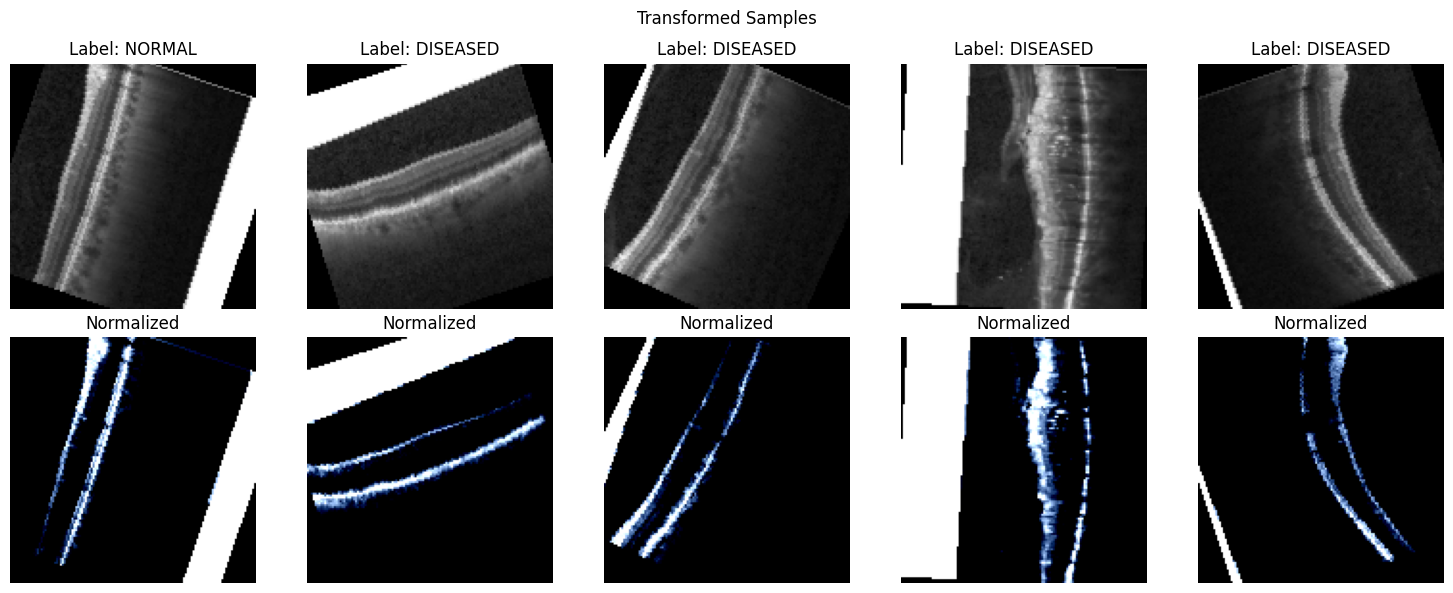

In [12]:
## Normalize and apply image transformation, and demonstrate some of the transformed samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
real_hr, labels = next(iter(dataloader))

for i in range(5):
    # Original (denormalized)
    axes[0, i].imshow(denormalize(real_hr[i]).permute(1, 2, 0))
    axes[0, i].set_title(f"Label: {'NORMAL' if labels[i]==0 else 'DISEASED'}")
    axes[0, i].axis('off')
    
    # Show normalized tensor values as heatmap
    axes[1, i].imshow(real_hr[i].permute(1, 2, 0))
    axes[1, i].set_title("Normalized")
    axes[1, i].axis('off')

plt.suptitle("Transformed Samples")
plt.tight_layout()
plt.show()

## Compare model A and model B

In [13]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return accuracy, f1, auc

# Load Model A
model_A = resnet18(weights=ResNet18_Weights.DEFAULT)
model_A.fc = nn.Linear(512, 2)
model_A.load_state_dict(torch.load('modelA.pth'))
model_A = model_A.to(device)

# Load Model B
model_B = resnet18(weights=ResNet18_Weights.DEFAULT)
model_B.fc = nn.Linear(512, 2)
model_B.load_state_dict(torch.load('modelB.pth'))
model_B = model_B.to(device)

# Evaluate both on the same test set
acc_A, f1_A, auc_A = evaluate_model(model_A, test_dataloader, device)
acc_B, f1_B, auc_B = evaluate_model(model_B, test_B_dataloader, device)

print("Model A (Real Images):")
print(f"  Accuracy: {acc_A:.4f} | F1: {f1_A:.4f} | AUC: {auc_A:.4f}")
print("\nModel B (SRGAN Generated Images):")
print(f"  Accuracy: {acc_B:.4f} | F1: {f1_B:.4f} | AUC: {auc_B:.4f}")

Model A (Real Images):
  Accuracy: 0.8619 | F1: 0.8834 | AUC: 0.9566

Model B (SRGAN Generated Images):
  Accuracy: 0.5653 | F1: 0.7115 | AUC: 0.4778
